# Evaluation of Reproduced Results for Weasel v2.0 and other classifiers

In [32]:
import glob
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', 20)

import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

import seaborn as sns
import os
from multi_comp_matrix import MCM
from IPython.display import Image, display

import sys
sys.path.append("../")



### Load reproduction result csvs

In [3]:
df = pd.read_csv("../benchmark/ucr-8-classifiers-accuracy-1.csv")
df_rt = pd.read_csv("../benchmark/ucr-8-classifiers-runtime-1.csv")

# need to filter down from 128 datasets to 114
ucr_114 = [
    "ACSF1", "Adiac", "ArrowHead", "Beef", "BeetleFly", "BirdChicken", "BME",
    "Car", "CBF", "Chinatown", "ChlorineConcentration", "CinCECGTorso",
    "Coffee", "Computers", "CricketX", "CricketY", "CricketZ", "Crop",
    "DiatomSizeReduction", "DistalPhalanxOutlineAgeGroup",
    "DistalPhalanxOutlineCorrect", "DistalPhalanxTW", "Earthquakes", "ECG200",
    "ECG5000", "ECGFiveDays", "ElectricDevices", "EOGHorizontalSignal",
    "EOGVerticalSignal", "EthanolLevel", "FaceAll", "FaceFour", "FacesUCR",
    "FiftyWords", "Fish", "FordA", "FordB", "FreezerRegularTrain",
    "FreezerSmallTrain", "GunPoint", "GunPointAgeSpan",
    "GunPointMaleVersusFemale", "GunPointOldVersusYoung", "Ham",
    "HandOutlines", "Haptics", "Herring", "HouseTwenty", "InlineSkate",
    "InsectEPGRegularTrain", "InsectEPGSmallTrain", "InsectWingbeatSound",
    "ItalyPowerDemand", "LargeKitchenAppliances", "Lightning2", "Lightning7",
    "Mallat", "Meat", "MedicalImages", "MiddlePhalanxOutlineAgeGroup",
    "MiddlePhalanxOutlineCorrect", "MiddlePhalanxTW",
    "MixedShapesRegularTrain", "MixedShapesSmallTrain", "MoteStrain",
    "NonInvasiveFetalECGThorax1", "NonInvasiveFetalECGThorax2", "OliveOil",
    "OSULeaf", "PhalangesOutlinesCorrect", "Phoneme",
    "PickupGestureWiimoteZ", "PigAirwayPressure", "PigArtPressure",
    "PigCVP", "Plane", "PowerCons", "ProximalPhalanxOutlineAgeGroup",
    "ProximalPhalanxOutlineCorrect", "ProximalPhalanxTW",
    "RefrigerationDevices", "Rock", "ScreenType", "SemgHandGenderCh2",
    "SemgHandMovementCh2", "SemgHandSubjectCh2", "ShakeGestureWiimoteZ",
    "ShapeletSim", "ShapesAll", "SmallKitchenAppliances", "SmoothSubspace",
    "SonyAIBORobotSurface1", "SonyAIBORobotSurface2", "StarLightCurves",
    "Strawberry", "SwedishLeaf", "Symbols", "SyntheticControl",
    "ToeSegmentation1", "ToeSegmentation2", "Trace", "TwoLeadECG",
    "TwoPatterns", "UMD", "UWaveGestureLibraryAll", "UWaveGestureLibraryX",
    "UWaveGestureLibraryY", "UWaveGestureLibraryZ", "Wafer", "Wine",
    "WordSynonyms", "Worms", "WormsTwoClass", "Yoga",
]

print(f"Loaded {len(df)} accuracy results and {len(df_rt)} runtime results")
df = df[df["Dataset"].isin(ucr_114)]
df_rt = df_rt[df_rt["Dataset"].isin(ucr_114)]

print(f"Filtered to {df['Dataset'].nunique()} datasets")

mapping = {
    "WEASEL 2.0":  "WEASEL 2.0 (D)",
    "WEASEL":      "WEASEL (D)",
    "MultiRocket": "MultiRocket (K)",
    "Rocket":      "Rocket (K)",
    "MiniRocket":  "MiniRocket (K)",
    "R_DST":       "R_DST (S)",
    "Hydra (K/D)": "Hydra (K/D)",
    "cBOSS (D)":       "cBOSS (D)",
}

for old, new in mapping.items():
    df.Classifier    = df.Classifier.replace({old: new})
    df_rt.Classifier = df_rt.Classifier.replace({old: new})


print(df_rt.head())
print(df.Classifier.value_counts())
print(df_rt.Classifier.value_counts())

Loaded 1023 accuracy results and 1023 runtime results
Filtered to 114 datasets
        Classifier    Dataset  Fit-Time  Predict-Time
0  MultiRocket (K)      ACSF1      3.17          1.83
1  MultiRocket (K)      Adiac      2.20          1.45
5  MultiRocket (K)  ArrowHead      0.46          1.15
6  MultiRocket (K)        BME      0.32          0.65
7  MultiRocket (K)       Beef      0.72          0.35
Classifier
MultiRocket (K)    114
R_DST (S)          114
Rocket (K)         114
MiniRocket (K)     114
WEASEL (D)         114
WEASEL 2.0 (D)     114
cBOSS (D)          114
Hydra (K/D)        113
Name: count, dtype: int64
Classifier
MultiRocket (K)    114
R_DST (S)          114
Rocket (K)         114
MiniRocket (K)     114
WEASEL (D)         114
WEASEL 2.0 (D)     114
cBOSS (D)          114
Hydra (K/D)        113
Name: count, dtype: int64


## Table Summary of Mean / Median for Each Classifier

In [4]:
acc = df.groupby("Classifier")["Accuracy"].agg(["mean", "median"]).add_prefix("Acc_")
fit = df_rt.groupby("Classifier")["Fit-Time"].agg(["mean", "median", ("total_hrs", lambda x: x.sum() / 3600)]).add_prefix("FitTime_")
pred = df_rt.groupby("Classifier")["Predict-Time"].agg(["mean", "median", ("total_hrs", lambda x: x.sum() / 3600)]).add_prefix("PredTime_")

acc.join([fit, pred]).round(4)

,Acc_mean,Acc_median,FitTime_mean,FitTime_median,FitTime_total_hrs,PredTime_mean,PredTime_median,PredTime_total_hrs
Classifier,,,,,,,,
Hydra (K/D),0.8577,0.9000,3.9615,0.520,0.1243,8.2864,0.870,0.2601
MiniRocket (K),0.8610,0.9090,1.5419,0.305,0.0488,0.4835,0.160,0.0153
MultiRocket (K),0.8666,0.9178,7.8041,1.835,0.2471,10.1562,2.750,0.3216
R_DST (S),0.8657,0.9038,14.3788,4.100,0.4553,20.6733,3.385,0.6547
Rocket (K),0.8571,0.9083,7.2625,1.910,0.2300,13.0450,3.355,0.4131
WEASEL (D),0.8258,0.8721,15.0304,2.445,0.4760,12.1904,1.500,0.3860
WEASEL 2.0 (D),0.8647,0.9275,17.9740,3.745,0.5692,21.7049,3.045,0.6873
cBOSS (D),0.8162,0.8581,237.0912,28.230,7.5079,32.4338,10.010,1.0271


## Identify if there are any missing datasets
### (StarLightCurves didn't run successfully for Hydra classifier)

In [5]:
pd.set_option('display.max_rows', 500)
df_pivot = df.pivot(index="Dataset", columns=["Classifier"], values=["Accuracy"])  # .iloc[:-5]

for clf in df_pivot.columns:
    missing = df_pivot[df_pivot[clf].isna()].index.tolist()
    if missing:
        print(f"{clf} missing {len(missing)}: {missing}")

df_pivot.reset_index(drop=True)
df_pivot.columns = df_pivot.columns.get_level_values(1)
#df_pivot.dropna(inplace=True)
df_pivot = df_pivot.round(4)

# display(df_pivot)
df_pivot.describe()

('Accuracy', 'Hydra (K/D)') missing 1: ['StarLightCurves']


Classifier,Hydra (K/D),MiniRocket (K),MultiRocket (K),R_DST (S),Rocket (K),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
count,113.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,0.857743,0.861029,0.866623,0.865706,0.857086,0.825839,0.864705,0.816184
std,0.145529,0.143274,0.138443,0.137039,0.148261,0.167969,0.143828,0.165888
min,0.318600,0.285900,0.358600,0.338100,0.282200,0.313300,0.347000,0.296400
25%,0.789700,0.798925,0.797825,0.798300,0.788225,0.752000,0.787075,0.714350
50%,0.900000,0.909050,0.917800,0.903850,0.908250,0.872150,0.927500,0.858150
75%,0.972200,0.970300,0.975850,0.979200,0.968275,0.965625,0.969675,0.950300
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df_pivot.describe().loc[["mean", "50%", "std"]].T.round(3)

,mean,50%,std
Classifier,,,
Hydra (K/D),0.858,0.900,0.146
MiniRocket (K),0.861,0.909,0.143
MultiRocket (K),0.867,0.918,0.138
R_DST (S),0.866,0.904,0.137
Rocket (K),0.857,0.908,0.148
WEASEL (D),0.826,0.872,0.168
WEASEL 2.0 (D),0.865,0.928,0.144
cBOSS (D),0.816,0.858,0.166


## Compare to paper results

In [7]:
paper_original_results = pd.read_csv("../data/ucr_feature_space.csv")

paper_weasel2 = (paper_original_results[paper_original_results["Classifier"] == "WEASEL 2.0"]
            [["Dataset", "Accuracy"]]
            .rename(columns={"Accuracy": "paper_acc"}))


In [8]:
repr_w2 = (
    df[df["Classifier"] == "WEASEL 2.0 (D)"]
    [["Dataset", "Accuracy"]]
    .rename(columns={"Accuracy": "repr_acc"})
)

# join original paper results with reproduced results
merged = paper_weasel2.merge(repr_w2, on="Dataset")
merged["diff"] = merged["repr_acc"] - merged["paper_acc"]
merged["abs_diff"] = merged["diff"].abs()

print(f"Paper datasets: {len(paper_weasel2)}")
print(f"Reproduced datasets: {len(repr_w2)}")

# we consider exact matches within 0.1% accuracy as exact reprodcution
reproduction_tolerance = 0.001
exact  = (merged["abs_diff"] <= reproduction_tolerance).sum()
higher_results = (merged["diff"] >  reproduction_tolerance).sum()
lower_results  = (merged["diff"] < -reproduction_tolerance).sum()

print(f"\nResults within tolerance: {exact}/{len(merged)}  ({exact/len(merged)*100:.1f}%)")
print(f"Reproduced HIGHER Results: {higher_results}")
print(f"Reproduced LOWER Results: {lower_results}")
print(f"Mean diff: {merged['diff'].mean():+.6f}")
print(f"Std diff: {merged['diff'].std():.6f}")


# we consider outliers as results that differ by more than 1% accuracy
outlier_threshold = 0.01

outliers = (
    merged[merged["abs_diff"] > outlier_threshold]
    .sort_values("diff", ascending=False)
    [["Dataset", "paper_acc", "repr_acc", "diff"]]
    .reset_index(drop=True)
)
outliers.columns = ["Dataset", "Paper", "Reproduced", "Outlier"]
print(f"\nOutliers: {len(outliers)}")
display(outliers.style.format({"Paper": "{:.4f}", "Reproduced": "{:.4f}", "Outlier": "{:+.4f}"}))



Paper datasets: 114
Reproduced datasets: 114

Results within tolerance: 76/114  (66.7%)
Reproduced HIGHER Results: 16
Reproduced LOWER Results: 22
Mean diff: +0.001489
Std diff: 0.014147

Outliers: 9


,Dataset,Paper,Reproduced,Outlier
0,PickupGestureWiimoteZ,0.7800,0.9000,+0.1200
1,ShakeGestureWiimoteZ,0.8800,0.9600,+0.0800
2,ScreenType,0.4770,0.4960,+0.0190
3,LargeKitchenAppliances,0.8210,0.8320,+0.0110
4,ProximalPhalanxOutlineCorrect,0.9110,0.9003,-0.0107
5,Worms,0.7270,0.7143,-0.0127
6,SmallKitchenAppliances,0.7890,0.7760,-0.0130
7,Lightning7,0.8360,0.8219,-0.0141
8,ACSF1,0.9600,0.9400,-0.0200


## Wilcoxon Test on Originak vs Reproduced

In [9]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(merged["repr_acc"], merged["paper_acc"])
print(f"Wilcoxon test: {stat:.4f}")
print(f"p-value: {p:.4f}")
print(f"Mean diff: {merged['diff'].mean():+.6f}")
print("Conclusion:", "significant difference" if p < 0.05 else "no significant difference detected")

Wilcoxon test: 2395.0000
p-value: 0.6549
Mean diff: +0.001489
Conclusion: no significant difference detected


## Best and Worst Datasets based on Reproduction Results

In [10]:
num_datasets = 10

print(f"Datasets with BETTER reproduced results")
better = (
    merged[merged["diff"] > reproduction_tolerance]
    .nlargest(num_datasets, "diff")
    [["Dataset", "paper_acc", "repr_acc", "diff"]]
)
display(better.style.format("{:.4f}", subset=["paper_acc", "repr_acc", "diff"]))

print(f"Datasets with WORSE reproduced results")
worse = (
    merged[merged["diff"] < -reproduction_tolerance]
    .nsmallest(num_datasets, "diff")
    [["Dataset", "paper_acc", "repr_acc", "diff"]]
)
display(worse.style.format("{:.4f}", subset=["paper_acc", "repr_acc", "diff"]))


Datasets with BETTER reproduced results


,Dataset,paper_acc,repr_acc,diff
54,PickupGestureWiimoteZ,0.7800,0.9000,0.1200
70,ShakeGestureWiimoteZ,0.8800,0.9600,0.0800
80,ScreenType,0.4770,0.4960,0.0190
62,LargeKitchenAppliances,0.8210,0.8320,0.0110
27,Ham,0.7520,0.7619,0.0099
59,EOGHorizontalSignal,0.6080,0.6160,0.0080
32,Computers,0.6920,0.7000,0.0080
43,MiddlePhalanxOutlineAgeGroup,0.6100,0.6169,0.0069
11,DistalPhalanxTW,0.6910,0.6978,0.0068
110,HandOutlines,0.9540,0.9595,0.0055


Datasets with WORSE reproduced results


,Dataset,paper_acc,repr_acc,diff
14,ACSF1,0.9600,0.9400,-0.0200
40,Lightning7,0.8360,0.8219,-0.0141
90,SmallKitchenAppliances,0.7890,0.7760,-0.0130
92,Worms,0.7270,0.7143,-0.0127
65,ProximalPhalanxOutlineCorrect,0.9110,0.9003,-0.0107
77,RefrigerationDevices,0.5650,0.5573,-0.0077
58,PhalangesOutlinesCorrect,0.8440,0.8392,-0.0048
15,DistalPhalanxOutlineCorrect,0.7830,0.7790,-0.0040
47,MiddlePhalanxOutlineCorrect,0.8350,0.8316,-0.0034
1,Chinatown,0.9770,0.9738,-0.0032


## Plot Critical Difference Diagrams

Datasets before: 114, after dropping NaN rows: 113
Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R_DST (S)',
       'Rocket (K)', 'WEASEL (D)', 'WEASEL 2.0 (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')
Classifier  Hydra (K/D)  MiniRocket (K)  MultiRocket (K)  R_DST (S)  \
Dataset                                                               
ACSF1            0.8800          0.9100           0.9000     0.9200   
Adiac            0.8210          0.8363           0.8286     0.7238   
ArrowHead        0.8114          0.8629           0.8629     0.8686   
BME              1.0000          1.0000           1.0000     0.9933   
Beef             0.8667          0.8333           0.7667     0.8333   

Classifier  Rocket (K)  WEASEL (D)  WEASEL 2.0 (D)  cBOSS (D)  
Dataset                                                        
ACSF1           0.8800      0.8700          0.9400     0.8900  
Adiac           0.7852      0.8107          0.8414     0.7903  
ArrowHead      

Classifer,Hydra (K/D),MiniRocket (K),MultiRocket (K),R_DST (S),Rocket (K),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Mean Rank,4.58,4.83,4.01,4.35,4.73,6.12,4.37,6.54


(0, 'Hydra (K/D)'):  	 ties/wins=(28, 12)
(1, 'MiniRocket (K)'):  	 ties/wins=(17, 5)
(2, 'MultiRocket (K)'):  	 ties/wins=(39, 22)
(3, 'R_DST (S)'):  	 ties/wins=(30, 15)
(4, 'Rocket (K)'):  	 ties/wins=(25, 6)
(5, 'WEASEL (D)'):  	 ties/wins=(14, 6)
(6, 'WEASEL 2.0 (D)'):  	 ties/wins=(28, 14)
(7, 'cBOSS (D)'):  	 ties/wins=(15, 3)
Total:  	113


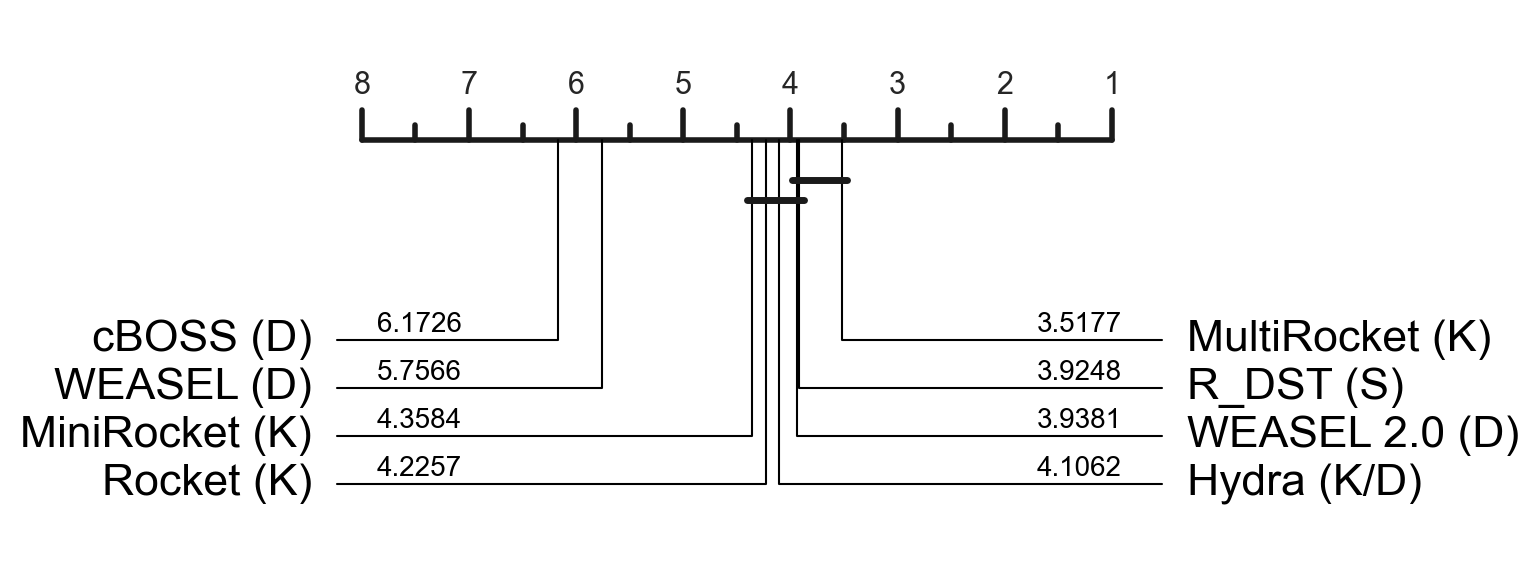

Classifer,Hydra (K/D),MiniRocket (K),MultiRocket (K),R_DST (S),Rocket (K),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Mean Rank,4.58,4.83,4.01,4.35,4.73,6.12,4.37,6.54


In [11]:
from aeon.visualisation import plot_critical_difference

def critical_difference(df_subset, show=True):
    ranks = df_subset.rank(1, method = 'max', ascending=False)
    # print(ranks)
    mean_ranks = np.array(ranks.mean(axis=0))

    df_ranks = pd.DataFrame(
        list(zip(df_subset.columns.values, np.round(mean_ranks,2))), 
        columns=["Classifer", "Mean Rank"]).set_index("Classifer").T
    
    if show:
        display(df_ranks)
        for i, name in enumerate(df_subset.columns[0:]):
           print(f"{i, name}:  \t ties/wins={ranks[ranks[name] == np.min(ranks, axis=1)].shape[0], ranks[ranks[name] == 1].shape[0]}")

        print(f"Total:  \t{len(ranks)}")

    fig, ax = plot_critical_difference(df_subset.values, list(df_subset.columns))
    
    plt.show()
    
    return df_ranks



df_subset = df_pivot 
df_clean = df_subset.dropna(axis=0)

print(f"Datasets before: {len(df_subset)}, after dropping NaN rows: {len(df_clean)}")

print(df_clean.columns)
print(df_clean.head())

critical_difference(df_clean)

Classifer,Hydra (K/D),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Mean Rank,2.18,3.1,2.14,3.3


(0, 'Hydra (K/D)'):  	 ties/wins=(56, 38)
(1, 'WEASEL (D)'):  	 ties/wins=(17, 8)
(2, 'WEASEL 2.0 (D)'):  	 ties/wins=(56, 36)
(3, 'cBOSS (D)'):  	 ties/wins=(21, 8)
Total:  	113


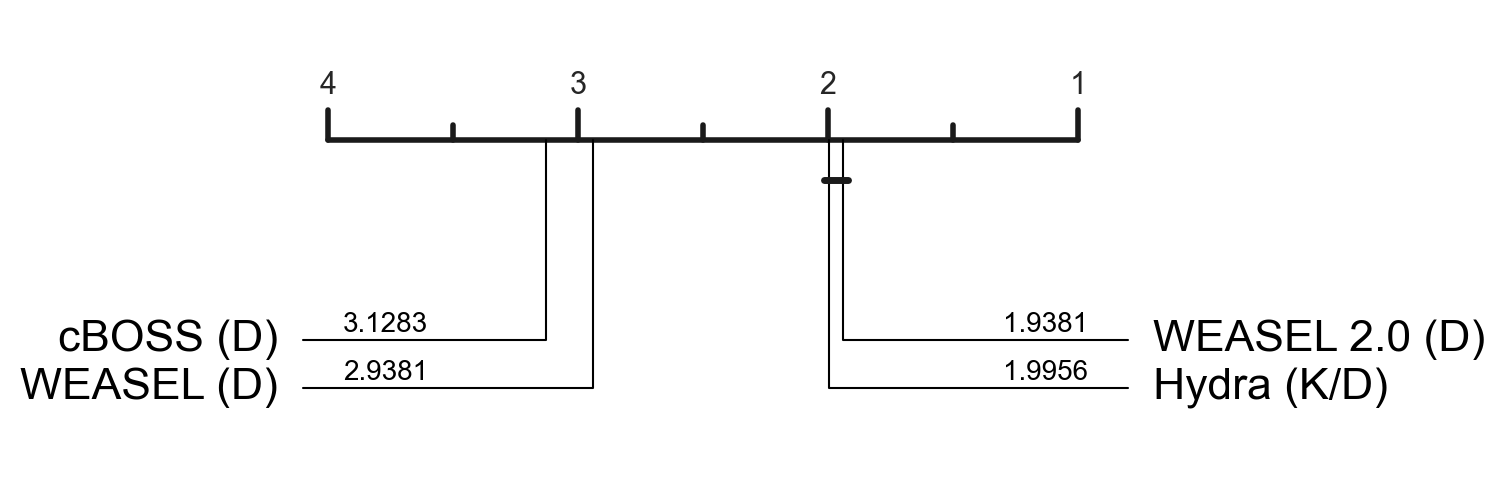

Classifer,Hydra (K/D),WEASEL (D),WEASEL 2.0 (D),cBOSS (D)
Mean Rank,2.18,3.1,2.14,3.3


In [12]:
subset = [0, 5,6,7] # plot just dictionary based methods
df_subset2 = df_clean.iloc[:, subset]
critical_difference(df_subset2, True)

In [13]:
print(df_clean.columns)
print(df_pivot.columns)

Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R_DST (S)',
       'Rocket (K)', 'WEASEL (D)', 'WEASEL 2.0 (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')
Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R_DST (S)',
       'Rocket (K)', 'WEASEL (D)', 'WEASEL 2.0 (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')


Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R_DST (S)',
       'Rocket (K)', 'WEASEL (D)', 'WEASEL 2.0 (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')


C:\Users\gerar\AppData\Local\Temp\ipykernel_19852\1019631997.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, fontsize=12, ha='left')


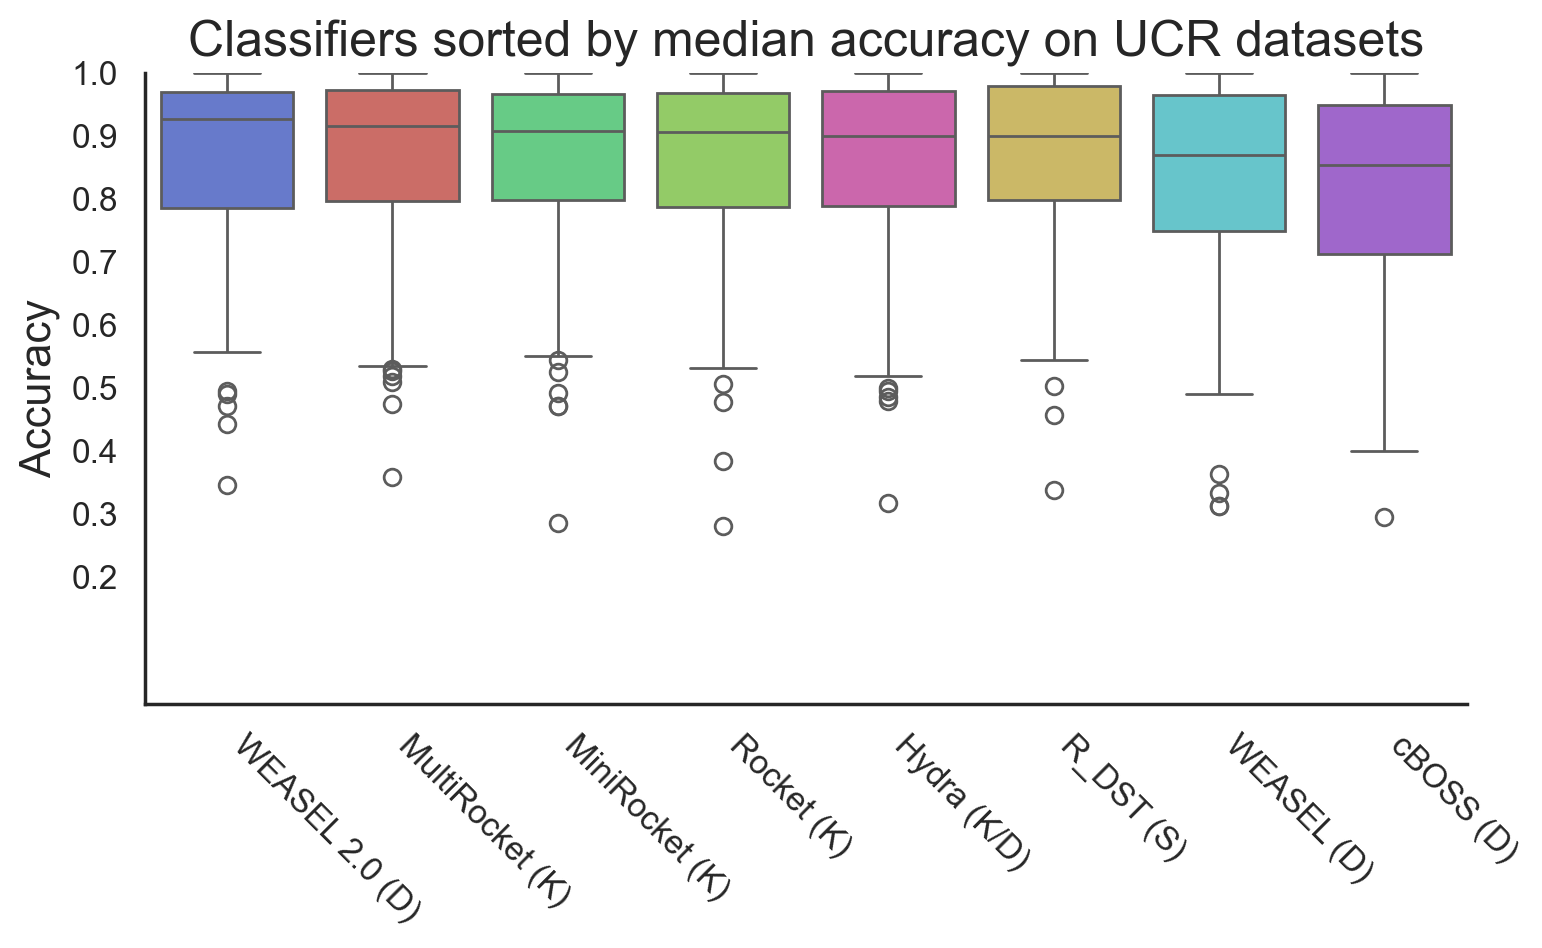

In [14]:
sns.set(font_scale=1.3)
sns.set_style("white")

print(df_clean.columns)
df_clean2 = df.dropna()


valid_datasets = df_clean.index  # datasets with no NaN across all classifiers
df_filtered = df[df["Dataset"].isin(valid_datasets)]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
g = sns.boxplot(y="Accuracy", 
                x="Classifier", 
                data=df_filtered, ax=ax, hue="Classifier", palette="hls",
                order=df_filtered.groupby("Classifier")["Accuracy"].median()
                      .sort_values(ascending=False).index)

ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, fontsize=12, ha='left')
ax.set_yticks(ax.get_yticks(), labels=ax.get_yticklabels(), fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0.0, 1.0)
ax.set_title("Classifiers sorted by median accuracy on UCR datasets", fontsize=18)
sns.despine()
plt.tight_layout()

In [15]:
#def color_negative_red(val):
#    color = 'red' if val < 0 else 'black'
#    return 'color: %s' % color

#subset = [14, 8]
#subset = df_pivot.iloc[:,subset].copy()
#subset["diff"] = np.int32((subset.iloc[:,1] - subset.iloc[:,0])*100)

ds_file_name = "ucr_characteristics.csv"
datasets = pd.read_csv(f"../data/{ds_file_name}")
print(datasets.head())
#df_new = pd.merge(subset, datasets, how ='inner', on =['Dataset', 'Dataset'])
#df_new.style.applymap(color_negative_red)
# df_new.to_excel("diff.xls")
#display(df_new)

              Dataset  Train Size  Test Size  Length  No. of Classes    Type
0   AbnormalHeartbeat         303        303    3053               5   AUDIO
1               ACSF1         100        100    1460              10  DEVICE
2               Adiac         390        391     176              37   IMAGE
3  AllGestureWiimoteX         300        700       0              10  MOTION
4  AllGestureWiimoteY         300        700       0              10  MOTION


In [16]:
subset = [4, 6, 8, 9, 10, 14]
df_subset2 = df_filtered #.iloc[:,subset].copy()
df_new = pd.merge(datasets, df_subset2, how ='inner', on =['Dataset', 'Dataset'])
# df_new = df_new.melt(id_vars=["Dataset", "Type"])
display(df_new.head())
df_new.to_csv("../data/ucr_subset_dataset_type.csv")

,Dataset,Train Size,Test Size,Length,No. of Classes,Type,Classifier,Accuracy,Train-Acc
0,ACSF1,100,100,1460,10,DEVICE,MultiRocket (K),0.90,0.00000
1,ACSF1,100,100,1460,10,DEVICE,R_DST (S),0.92,0.00000
2,ACSF1,100,100,1460,10,DEVICE,Rocket (K),0.88,0.00000
3,ACSF1,100,100,1460,10,DEVICE,MiniRocket (K),0.91,0.00000
4,ACSF1,100,100,1460,10,DEVICE,WEASEL (D),0.87,-0.25196


In [17]:
import warnings
warnings.simplefilter("ignore", UserWarning)
# warnings.simplefilter("ignore", FutureWarning)


#ds_file_name = "ucr_characteristics.csv"
#datasets = pd.read_csv(f"../data/{ds_file_name}")
#for t in datasets.Type.unique():
#    df_new = pd.merge(df_subset.reset_index(), datasets[datasets.Type==t], how ='inner', on =['Dataset', 'Dataset'])
#    df_new = df_new.iloc[:,:df_subset.shape[1]+1].set_index("Dataset")
#    if df_new.shape[0] > 2:
#        print(t, len(df_new))
#        df_ranks = critical_difference(df_new, False)
#        plt.show()        
#        display(df_ranks)

df_rt.head()

,Classifier,Dataset,Fit-Time,Predict-Time
0,MultiRocket (K),ACSF1,3.17,1.83
1,MultiRocket (K),Adiac,2.20,1.45
5,MultiRocket (K),ArrowHead,0.46,1.15
6,MultiRocket (K),BME,0.32,0.65
7,MultiRocket (K),Beef,0.72,0.35


## Reproduced Train / Predict / Total Times for 8 Classifiers 

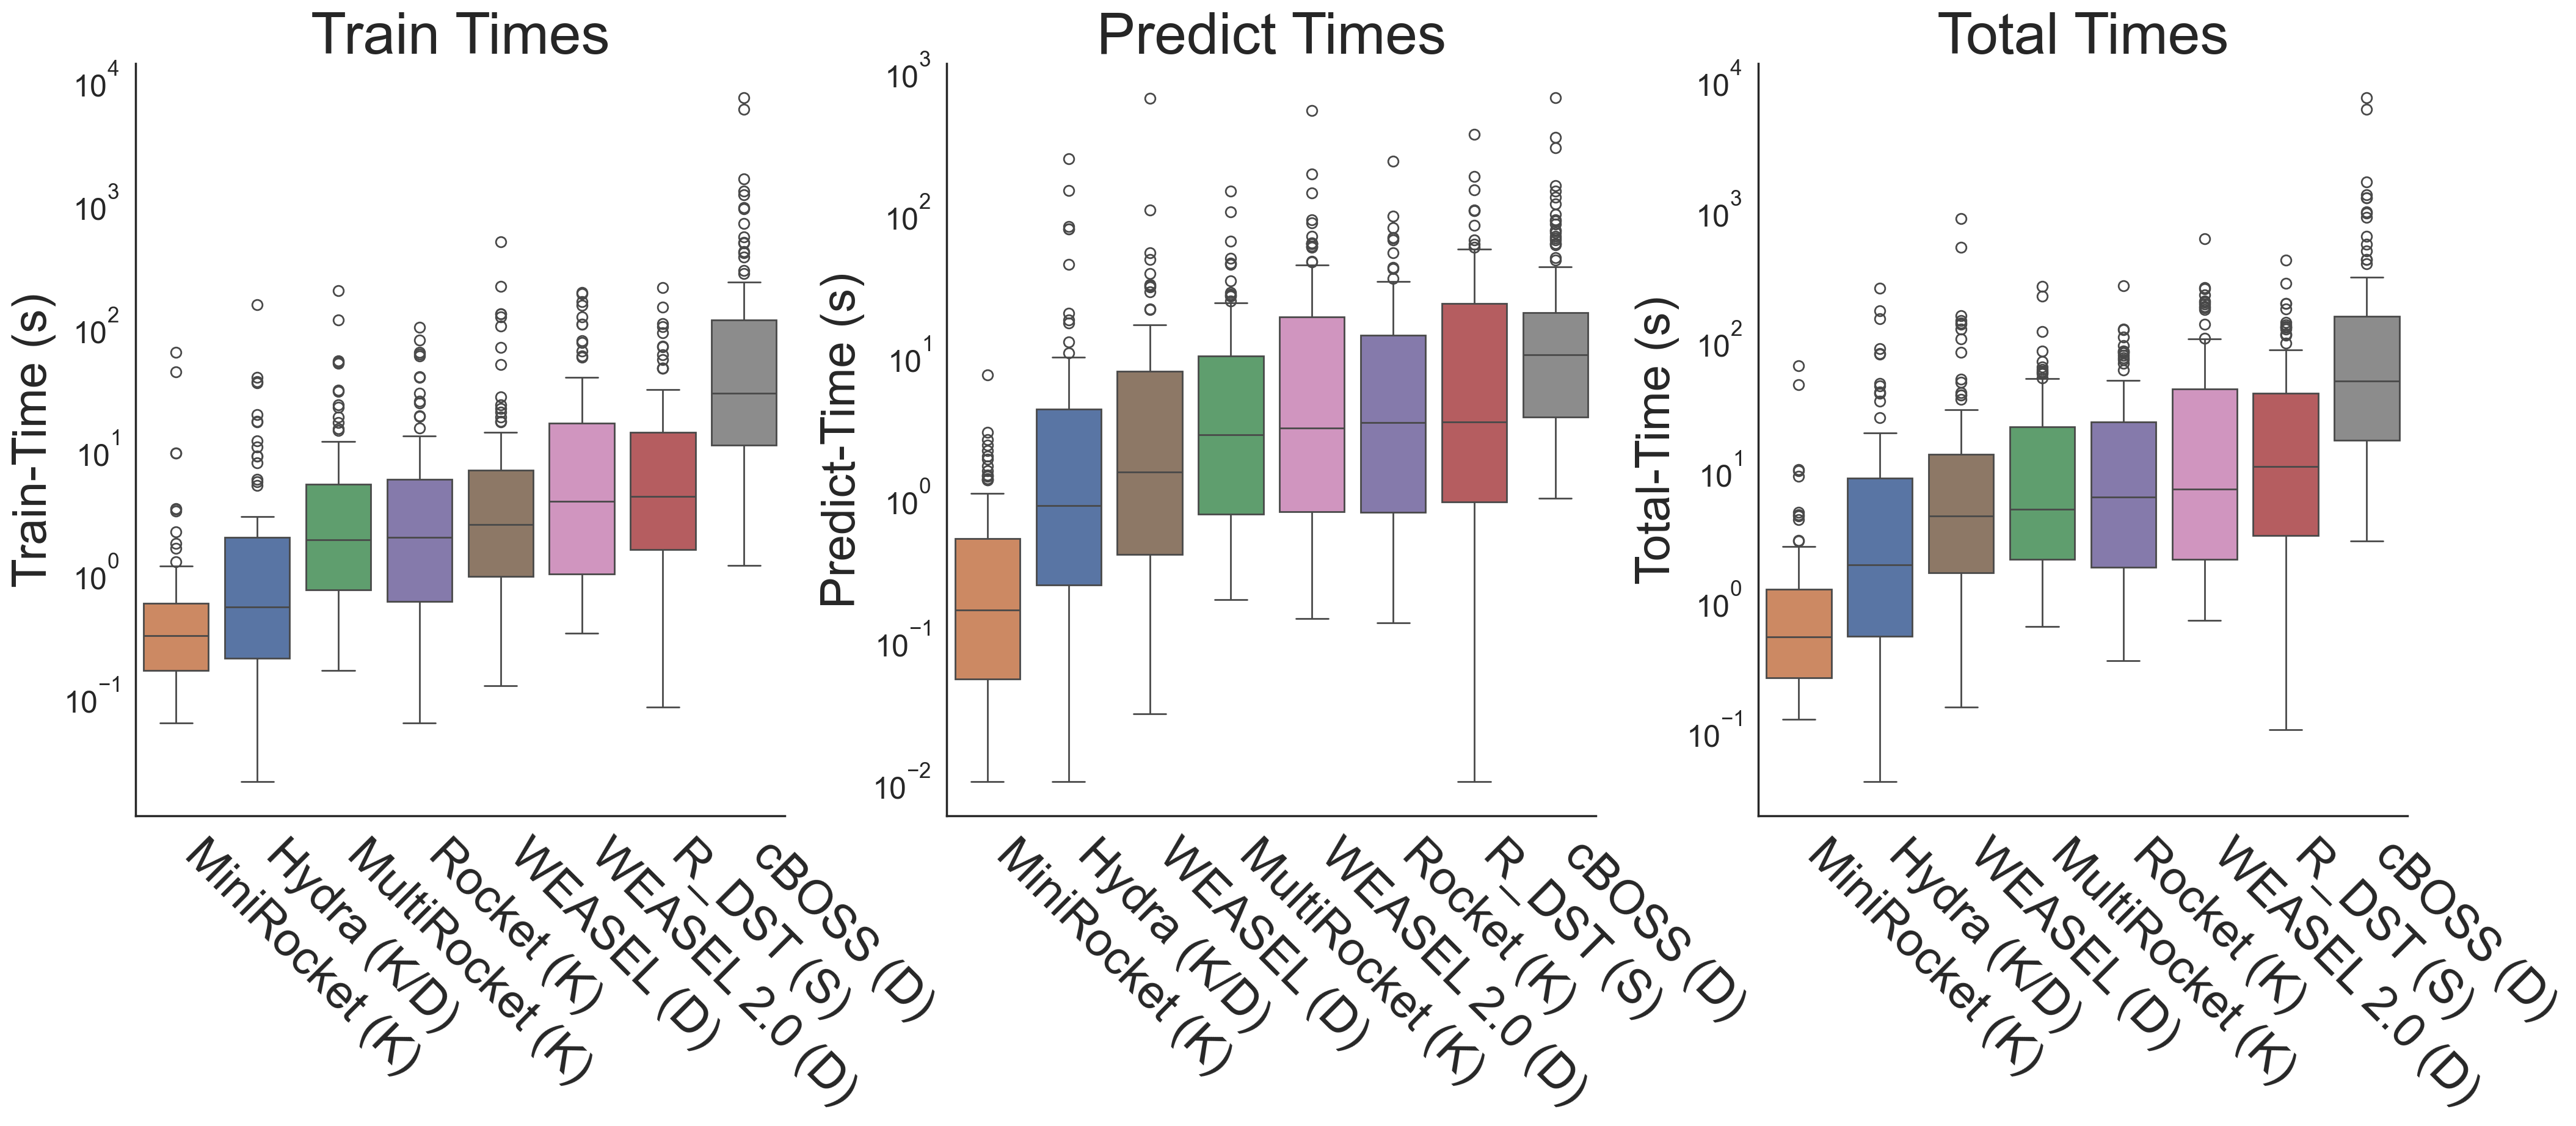

In [42]:
# Global font sizing — do this once, before plotting
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
})

sns.set(font_scale=2.0)
sns.set_style("white")

# fixed color mapping for boxplots
classifiers = sorted(df_rt["Classifier"].unique())
palette_colors = sns.color_palette("deep", n_colors=len(classifiers))
palette = dict(zip(classifiers, palette_colors))

df_rt.rename(columns={"Fit-Time": "Train-Time"}, inplace=True)
df_rt.dropna(inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(24, 8), gridspec_kw={'wspace': 0.25})

# --- Train Times ---
g = sns.boxplot(y="Train-Time", x="Classifier",
                 data=df_rt.sort_values(by="Classifier"), ax=axes[0], hue="Classifier",
                 order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                     by="Train-Time", ascending=True).reset_index()["Classifier"], palette=palette)
ax = axes[0]
g.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left', fontsize=28)
ax.tick_params(axis='y', labelsize=18)
ax.set_xlabel("")
ax.set_ylabel("Train-Time (s)", fontsize=28)
ax.set_title("Train Times", fontsize=34)
if ax.legend_ is not None:
    ax.legend_.remove()

# --- Predict Times ---
g = sns.boxplot(y="Predict-Time", x="Classifier",
                 data=df_rt.sort_values(by="Classifier"), ax=axes[1], hue="Classifier",
                 order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                     by="Predict-Time", ascending=True).reset_index()["Classifier"], palette=palette)
ax = axes[1]
g.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left', fontsize=28)
ax.tick_params(axis='y', labelsize=18)
ax.set_xlabel("")
ax.set_ylabel("Predict-Time (s)", fontsize=28)
ax.set_title("Predict Times", fontsize=34)
if ax.legend_ is not None:
    ax.legend_.remove()

# --- Total Times ---
df_rt["Total-Time"] = df_rt["Train-Time"] + df_rt["Predict-Time"]
g = sns.boxplot(y="Total-Time", x="Classifier",
                 data=df_rt.sort_values(by="Classifier"), ax=axes[2], hue="Classifier",
                 order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                     by="Total-Time", ascending=True).reset_index()["Classifier"], palette=palette)
ax = axes[2]
g.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left', fontsize=28)
ax.tick_params(axis='y', labelsize=18)
ax.set_xlabel("")
ax.set_ylabel("Total-Time (s)", fontsize=28)
ax.set_title("Total Times", fontsize=34)
if ax.legend_ is not None:
    ax.legend_.remove()

sns.despine()
plt.tight_layout()
plt.show()

In [19]:
df_pivot_rt = df_rt.pivot(index="Dataset", columns=["Classifier"], values=["Train-Time", "Predict-Time"])
pd.DataFrame({'sum': (df_pivot_rt.sum() / 60 / 60)})

sum
             Classifier               
Train-Time   Hydra (K/D)      0.124347
             MiniRocket (K)   0.048828
             MultiRocket (K)  0.247131
             R_DST (S)        0.455328
             Rocket (K)       0.229981
             WEASEL (D)       0.475964
             WEASEL 2.0 (D)   0.569178
             cBOSS (D)        7.507889
Predict-Time Hydra (K/D)      0.260100
             MiniRocket (K)   0.015311
             MultiRocket (K)  0.321614
             R_DST (S)        0.654656
             Rocket (K)       0.413092
             WEASEL (D)       0.386031
             WEASEL 2.0 (D)   0.687322
             cBOSS (D)        1.027069

In [20]:
#pd.set_option('display.max_rows', 1000)
#display(df_pivot_rt)
df_rt # .head()

,Classifier,Dataset,Train-Time,Predict-Time
0,MultiRocket (K),ACSF1,3.17,1.83
1,MultiRocket (K),Adiac,2.20,1.45
5,MultiRocket (K),ArrowHead,0.46,1.15
6,MultiRocket (K),BME,0.32,0.65
7,MultiRocket (K),Beef,0.72,0.35
...,...,...,...,...
1018,Hydra (K/D),Wine,0.13,0.10
1019,Hydra (K/D),WordSynonyms,0.60,1.19
1020,Hydra (K/D),Worms,1.52,0.66
1021,Hydra (K/D),WormsTwoClass,1.53,0.66


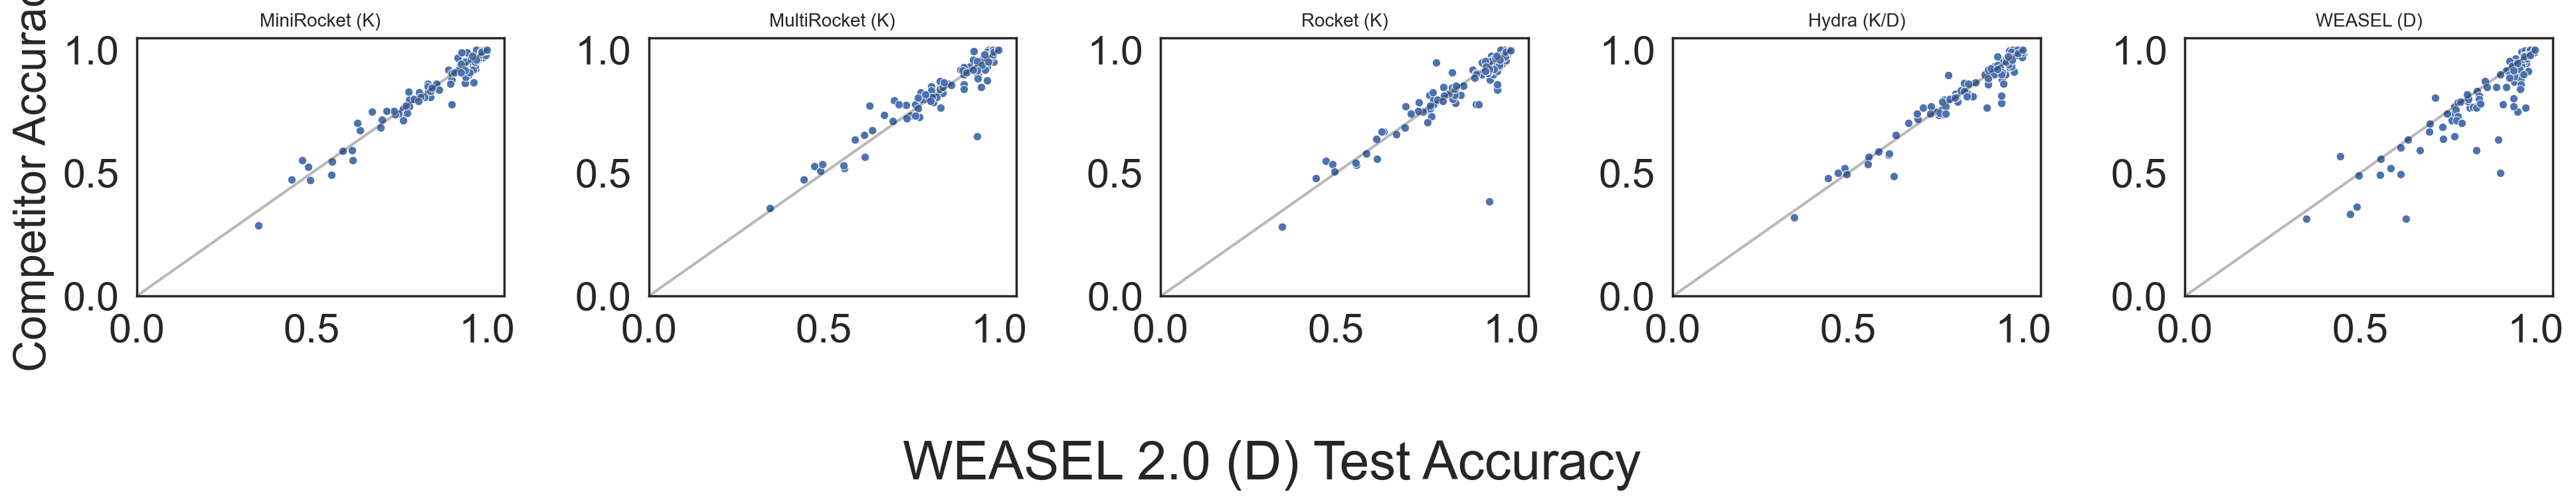

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
competitors = ["MiniRocket (K)", "MultiRocket (K)", "Rocket (K)", "Hydra (K/D)", "WEASEL (D)"]
key = "WEASEL 2.0 (D)"

for ax, comp in zip(axes, competitors):
    sns.scatterplot(x=key, y=comp, data=df_subset, ax=ax, s=20)
    ax.plot([0, 1], [0, 1], 'k-', alpha=0.3)
    ax.set_title(comp, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("Competitor Accuracy")
fig.supxlabel("WEASEL 2.0 (D) Test Accuracy")
plt.tight_layout()
plt.savefig("scatter_grid.png", dpi=150, bbox_inches="tight")

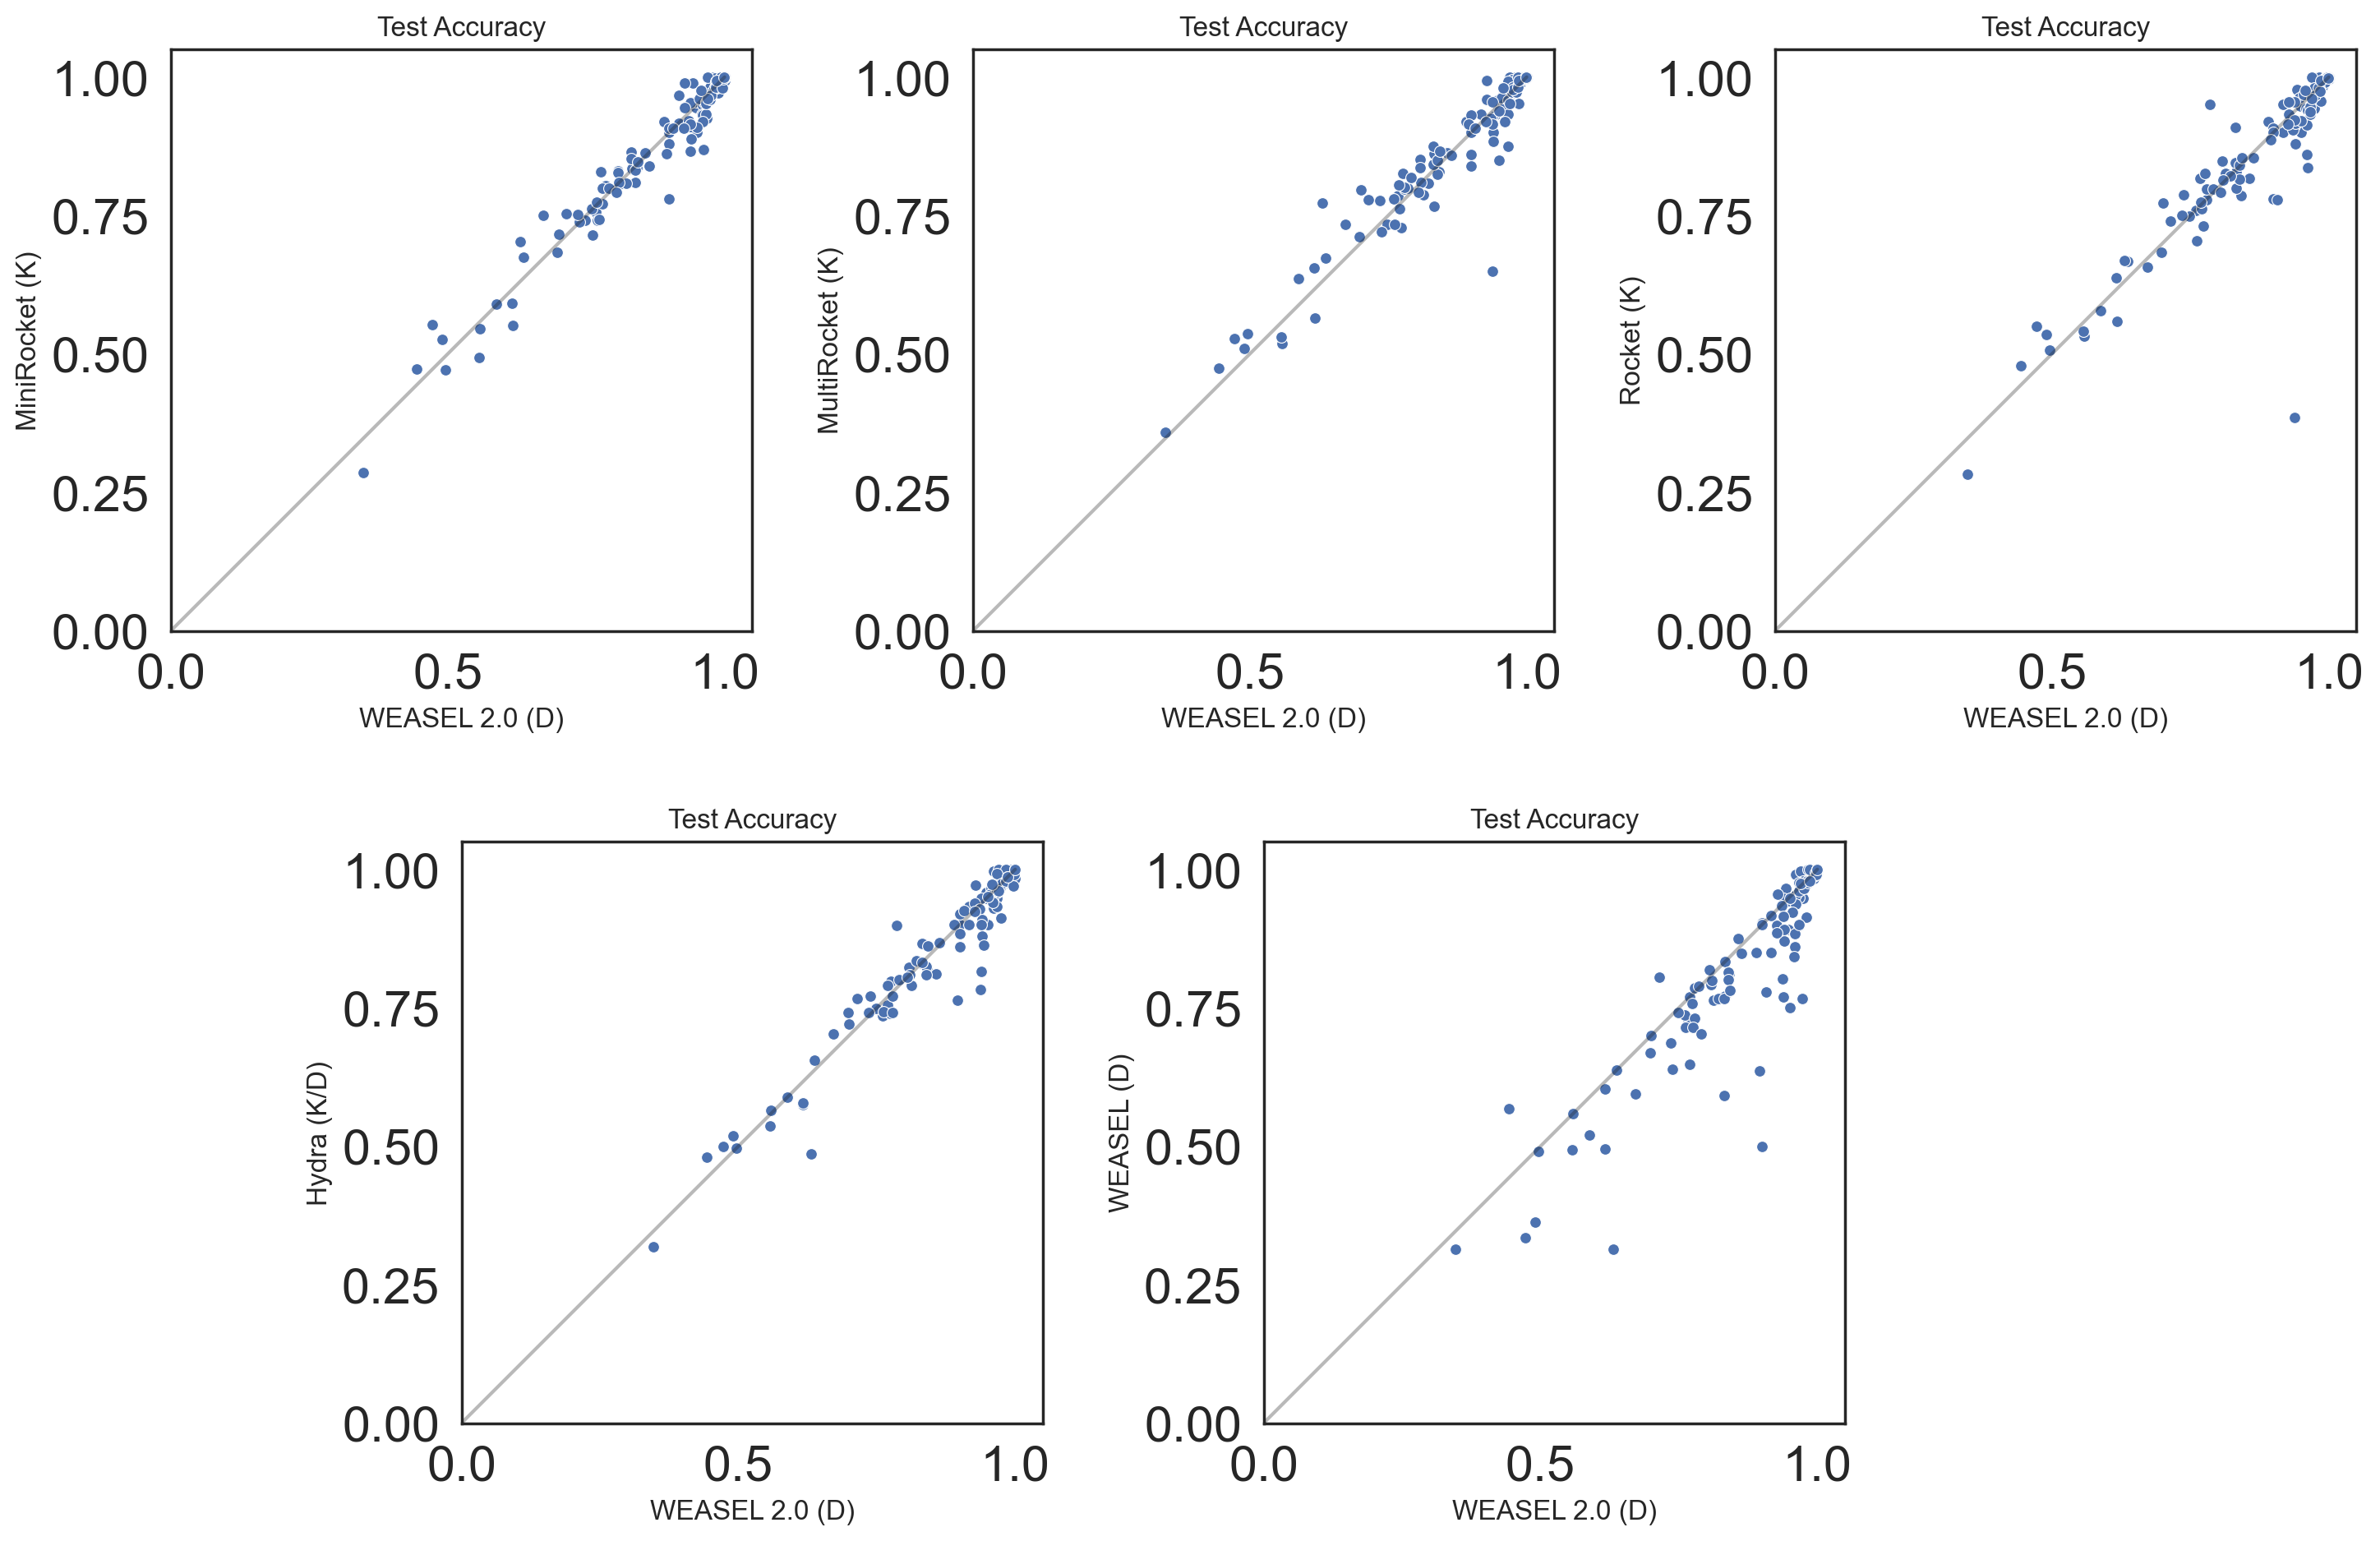

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
competitors = ["MiniRocket (K)", "MultiRocket (K)", "Rocket (K)", "Hydra (K/D)", "WEASEL (D)"]
key = "WEASEL 2.0 (D)"

# Flatten axes for easy iteration
axes_flat = axes.flatten()

for ax, comp in zip(axes_flat, competitors):
    sns.scatterplot(x=key, y=comp, data=df_subset, ax=ax, s=25)
    ax.plot([0, 1], [0, 1], 'k-', alpha=0.3)
    ax.set_title(f"Test Accuracy", fontsize=12)
    ax.set_xlabel("WEASEL 2.0 (D)", fontsize=12)
    ax.set_ylabel(comp, fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_aspect('equal')

axes_flat[5].set_visible(False) # hide the empty 6th subplot
plt.tight_layout()

# centre bottom two plots
pos1 = axes[1, 0].get_position()
pos2 = axes[1, 1].get_position()

shift = pos1.width / 2

axes[1, 0].set_position([pos1.x0 + shift, pos1.y0, pos1.width, pos1.height])
axes[1, 1].set_position([pos2.x0 + shift, pos2.y0, pos2.width, pos2.height])
plt.savefig("scatter_grid.png", dpi=150, bbox_inches="tight")
plt.show()

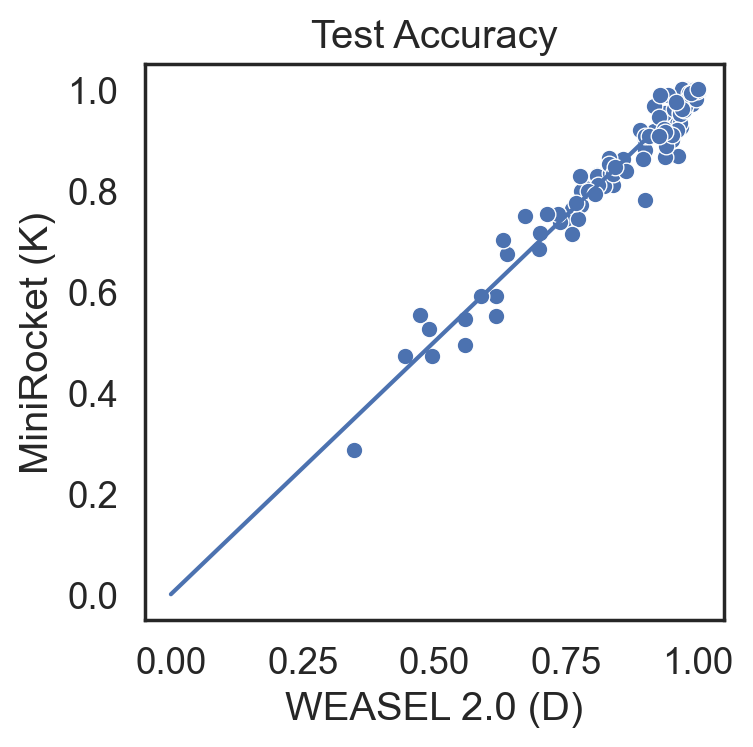

In [23]:
sns.set(font_scale=1.2)
sns.set_style("white")

key = "WEASEL 2.0 (D)"
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(x=key, y="MiniRocket (K)", data=df_subset)
ax.plot(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))
ax.set_title("Test Accuracy")
plt.tight_layout()

## Weasel 2.0 by UCR Dataset Type vs 5 SoTA Classifiers

In [24]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_weasel_UCR_comparison(df_pivot, datasets, clf_map, weasel_key,
                              type_col="Type", dataset_col="Dataset",
                              figsize=(30, 10)):

    clf_cols = list(clf_map.values())
    df = df_pivot[clf_cols].copy().reset_index()

    inv_map = {v: k for k, v in clf_map.items()}
    df = df.rename(columns=inv_map)
    clean_clfs = list(clf_map.keys())

    df = df.merge(datasets[[dataset_col, type_col]], on=dataset_col)
    df = df.dropna(subset=clean_clfs)
    df = df.sort_values([type_col, dataset_col]).reset_index(drop=True)

    df[clean_clfs] = df[clean_clfs] * 100

    df["min_acc"] = df[clean_clfs].min(axis=1)
    df["max_acc"] = df[clean_clfs].max(axis=1)

    weasel = df[weasel_key]
    others = [c for c in clean_clfs if c != weasel_key]
    best_other = df[others].max(axis=1)

    win = weasel > best_other
    tie = weasel == best_other
    loss = weasel < best_other

    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=figsize)

    ax.fill_between(x, df["min_acc"], df["max_acc"],
                    color="#e6a571", alpha=0.8)

    ax.plot(x, weasel, color="black", linestyle="--", linewidth=2.0)  # thicker

    ax.scatter(x[win], weasel[win], color="green", s=50, zorder=3)   # bigger dots
    ax.scatter(x[tie], weasel[tie], color="green", s=50, zorder=3)
    ax.scatter(x[loss], weasel[loss], color="red", s=50, zorder=3)

    groups = df.groupby(type_col, sort=False)
    boundaries = groups.size().cumsum()

    start = 0
    for (t, group), end in zip(groups, boundaries):
        ax.axvline(end - 0.5, linestyle="--", color="black", linewidth=0.5)
        mid = (start + end - 1) / 2
        ax.text(
            mid,
            20,
            t.upper(),
            rotation=-90,
            ha="center",
            va="bottom",
            fontsize=18,
            fontweight="bold",
        )
        start = end

    ax.set_ylabel("Test Accuracy", fontsize=18, fontweight="bold")
    ax.set_title("UCR/UEA Datasets ordered by Dataset-Type", fontsize=20, fontweight="bold")

    ax.set_ylim(0, 105)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_yticklabels([f"{i}%" for i in range(0, 101, 20)], fontsize=11)

    # Hide x labels entirely - type labels are enough
    ax.set_xticks([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_elements = [
        Patch(facecolor="#e6a571", edgecolor="none", label="5 SotA classifiers"),
        Line2D([0], [0], color="black", linestyle="--", label="WEASEL 2.0")
    ]
    ax.legend(handles=legend_elements, loc="lower right", frameon=True, fontsize=11)

    plt.tight_layout()
    plt.savefig("ucr_dataset_by_type.png", dpi=300, bbox_inches="tight")
    plt.show()

    return df

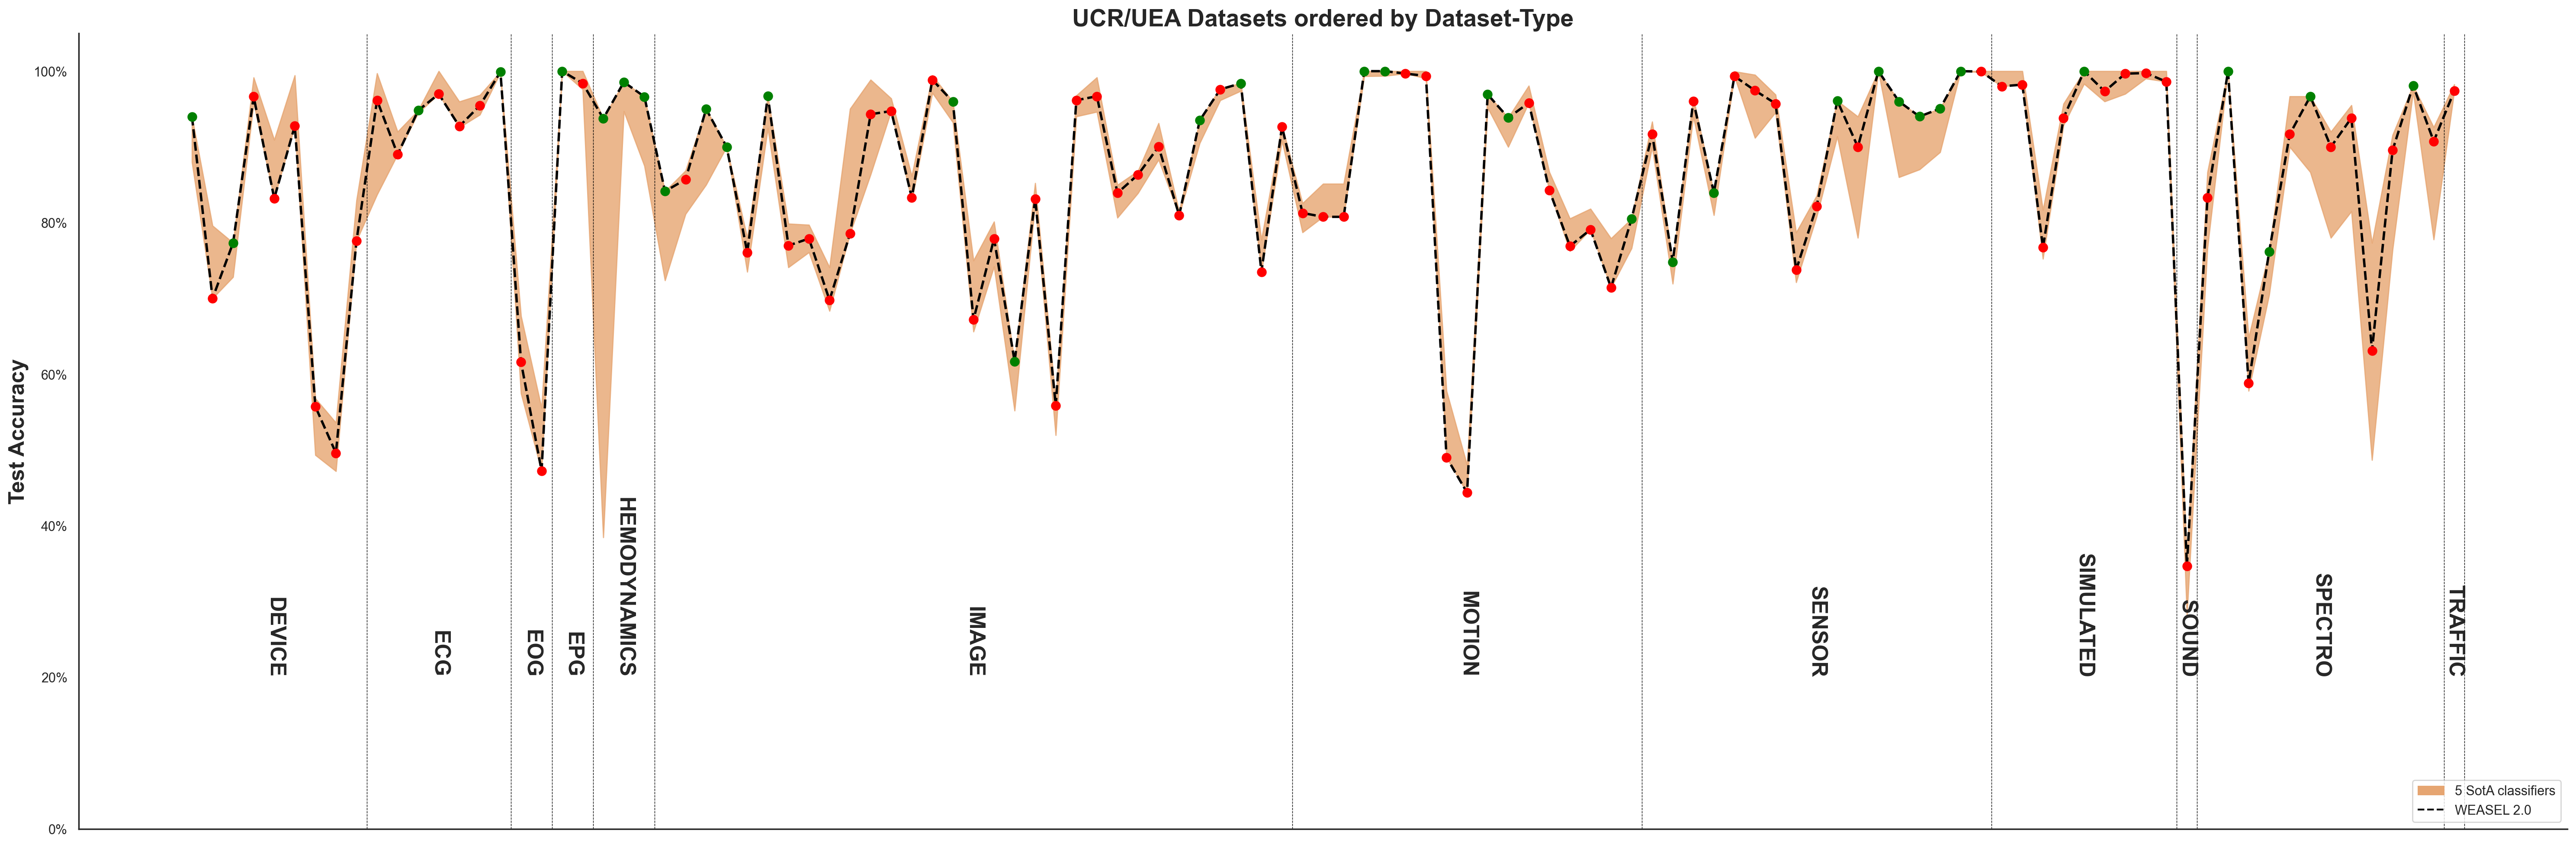

,Dataset,WEASEL 2.0,R-DST,MultiRocket,MiniRocket,Rocket,Hydra,Type,min_acc,max_acc
0,ACSF1,94.00,92.00,90.00,91.00,88.00,88.00,DEVICE,88.00,94.00
1,Computers,70.00,75.60,79.60,71.60,77.20,72.00,DEVICE,70.00,79.60
2,ElectricDevices,77.34,73.70,72.83,74.31,73.08,73.95,DEVICE,72.83,77.34
3,HouseTwenty,96.64,96.64,99.16,96.64,96.64,95.80,DEVICE,95.80,99.16
4,LargeKitchenAppliances,83.20,84.53,87.47,86.40,90.93,86.67,DEVICE,83.20,90.93
5,PowerCons,92.78,99.44,99.44,98.89,93.33,97.22,DEVICE,92.78,99.44
6,RefrigerationDevices,55.73,56.80,53.07,49.33,54.13,53.60,DEVICE,49.33,56.80
7,ScreenType,49.60,50.40,53.60,47.20,50.67,49.60,DEVICE,47.20,53.60
8,SmallKitchenAppliances,77.60,81.87,82.67,82.93,82.67,79.73,DEVICE,77.60,82.93
9,CinCECGTorso,96.16,99.28,94.93,86.88,83.70,99.71,ECG,83.70,99.71


In [25]:
clf_map = {
    "WEASEL 2.0": mapping["WEASEL 2.0"],
    "R-DST": mapping["R_DST"],
    "MultiRocket": mapping["MultiRocket"],
    "MiniRocket": mapping["MiniRocket"],
    "Rocket": mapping["Rocket"],
    "Hydra": mapping["Hydra (K/D)"],
}

plot_weasel_UCR_comparison(
    df_pivot,
    datasets,
    clf_map,
    "WEASEL 2.0"
)

## Accuracy vs Runtime Tradeoff for 8 Classifiers (Figure 6)

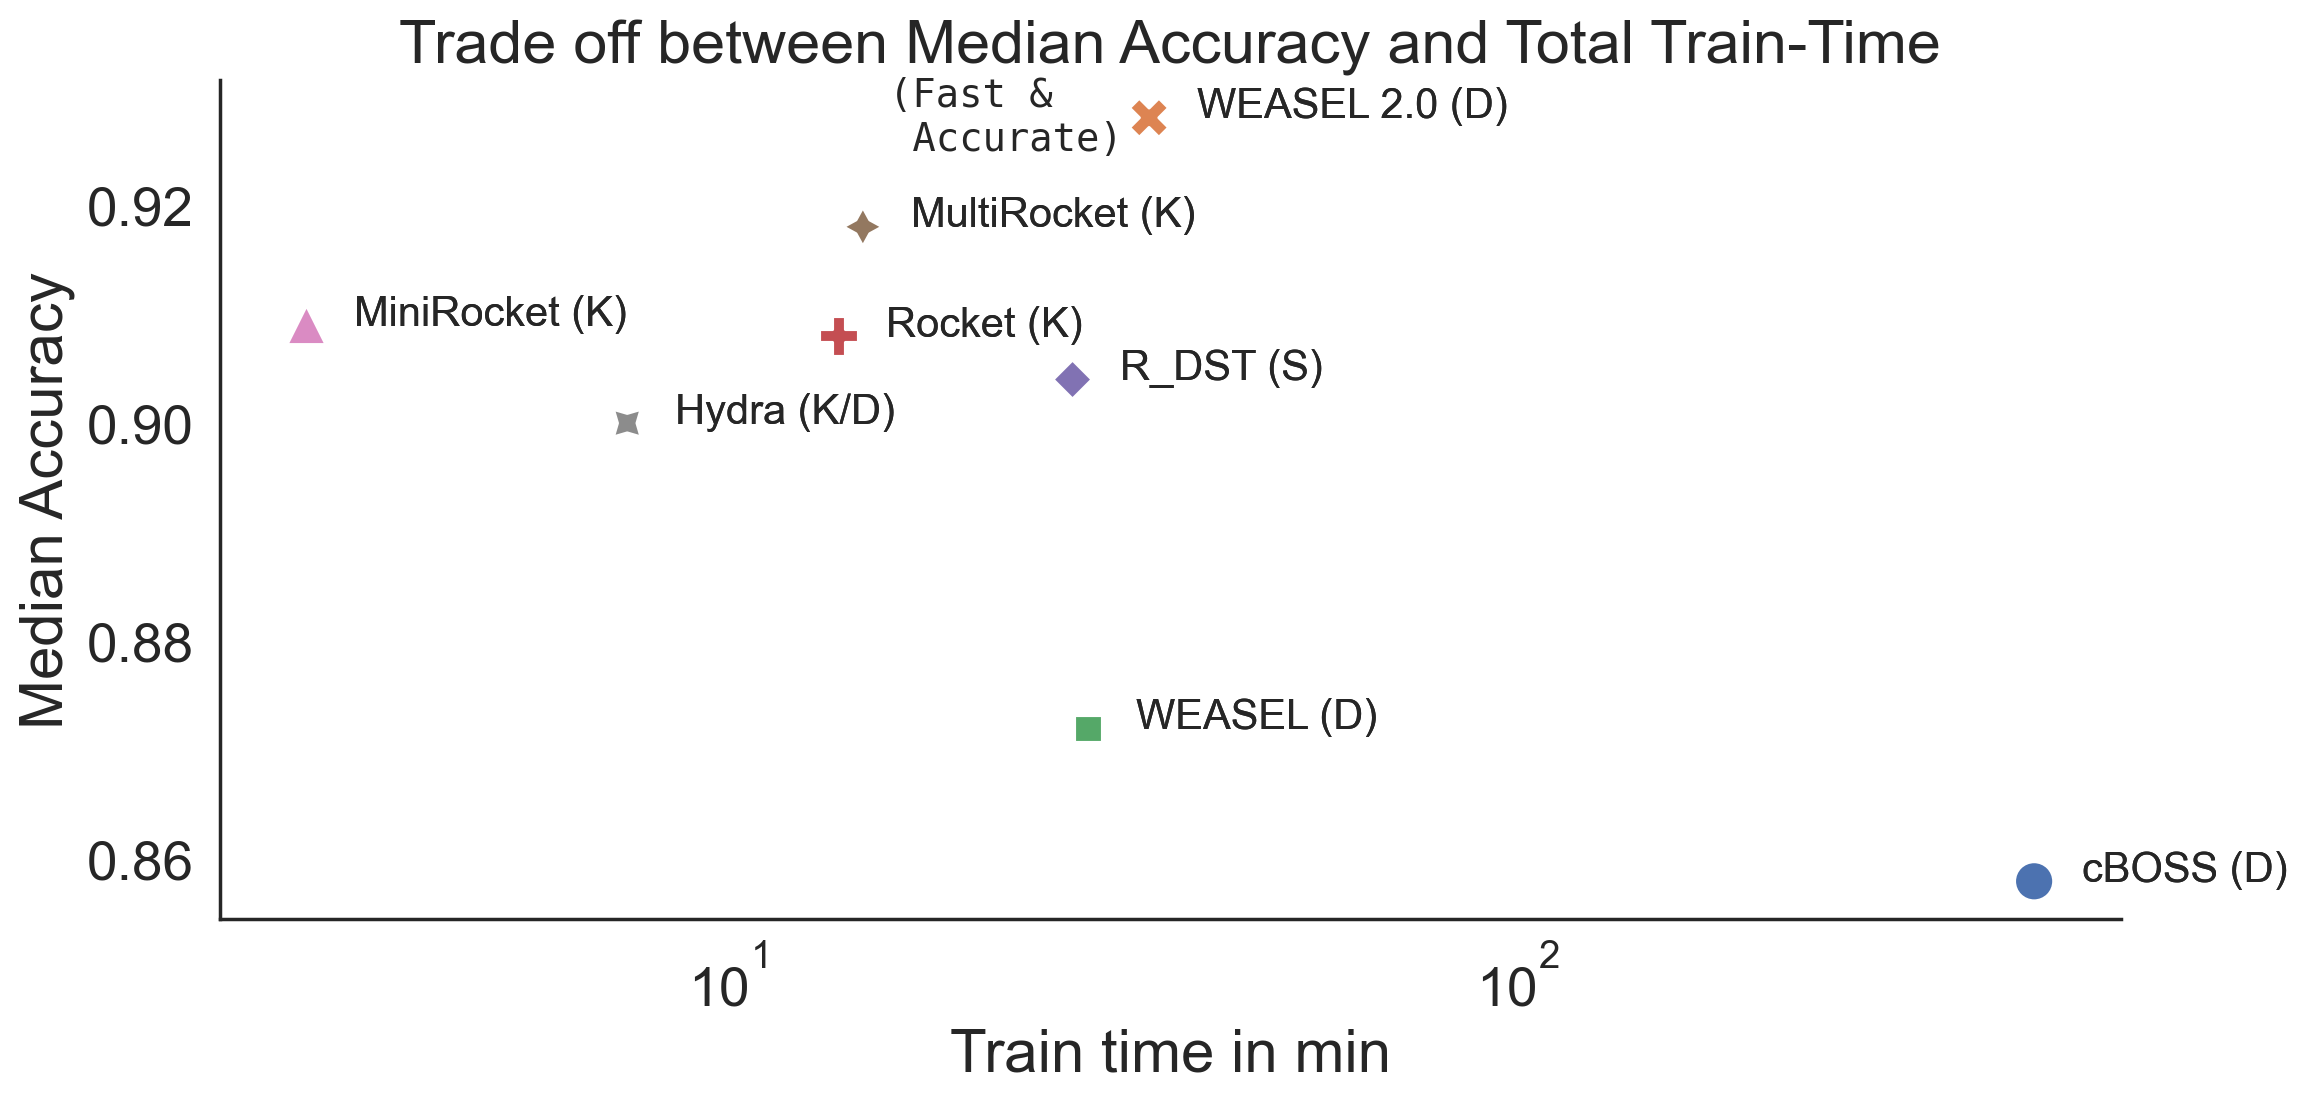

In [26]:
def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x']*1.15, point['y'], str(point['val']), fontsize=15)
        
sns.set(font_scale=1.8)
sns.set_style("white")

df_all = pd.DataFrame(columns=["Classifier", "Train time in min", "Acc"])
df = df_pivot_rt["Train-Time"]
for name in df_pivot_rt.columns[0:]:
    if name[1] in df_pivot:
        acc = np.round(df_pivot[name[1]].median(), 3)
        # print(name[1], acc)
        if name[1] in df:
            fit = np.round(df[name[1]].sum(), 3) / 60
            df_all.loc[-1] = [name[1], fit, acc]
            df_all.index = df_all.index + 1
df_all.sort_index(inplace=True)

# fig = plt.figure(figsize=(5, 5))
g = sns.relplot(x="Train time in min", y = "Acc", 
                kind="scatter", aspect=1.5, height=6,
                data=df_all, hue="Classifier", 
                style="Classifier", s=200)
g.ax.set_xscale("log")
g.ax.set_ylabel("Median Accuracy")

# add title
g.ax.set_title("Trade off between Median Accuracy and Total Train-Time", fontsize=22)

# annotate plot
g.ax.annotate('(Fast & \n Accurate)', xy=(16, 0.93), xytext=(16, 0.925),
             fontsize=14,fontfamily='monospace', ha='left');

label_point(df_all["Train time in min"], df_all["Acc"], df_all["Classifier"], plt.gca())  
g._legend.remove()
plt.tight_layout()

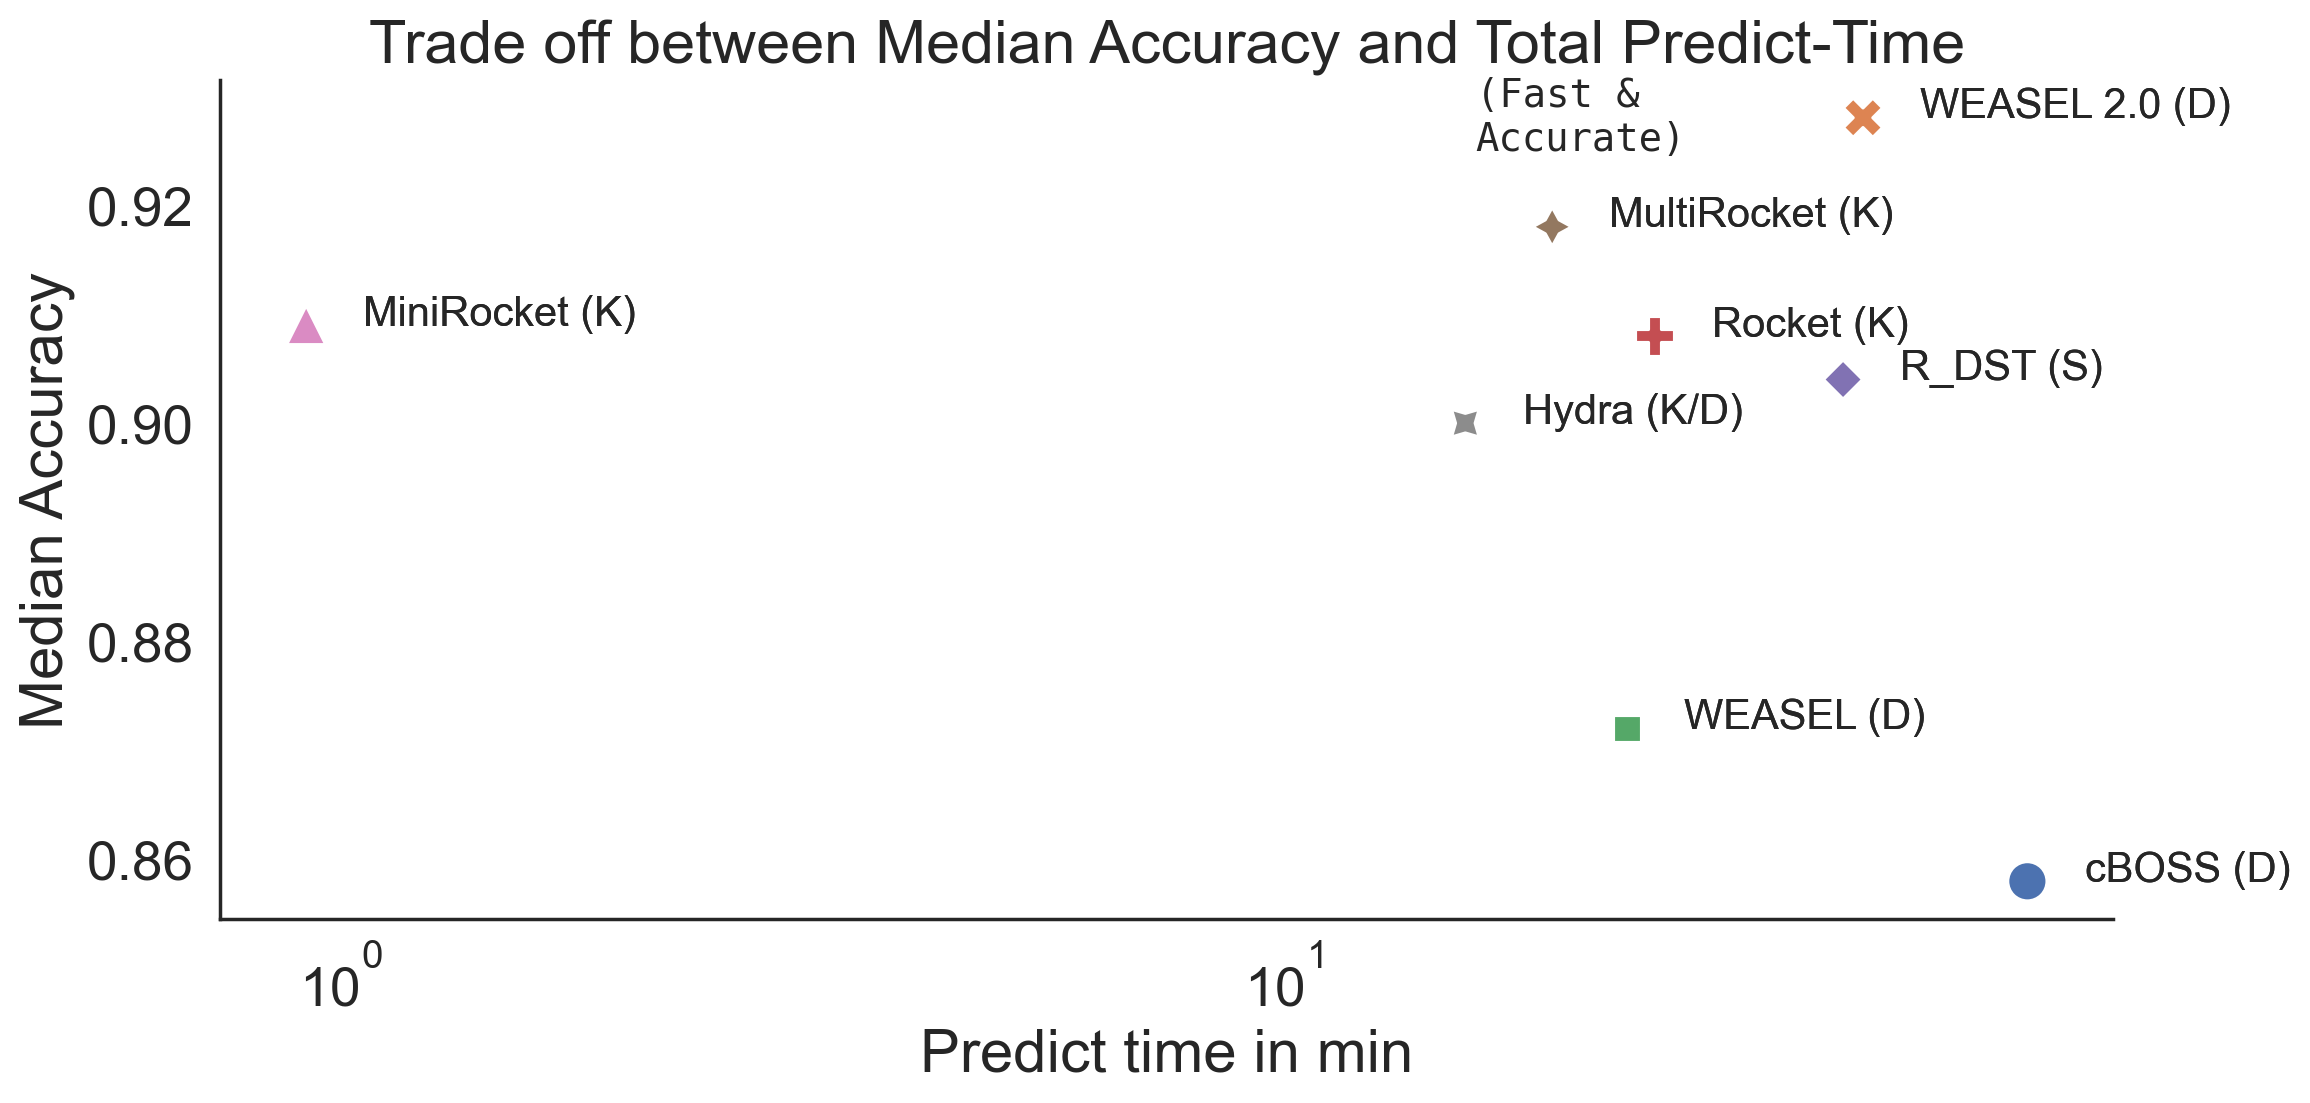

In [27]:
sns.set(font_scale=1.8)
sns.set_style("white")

df_all = pd.DataFrame(columns=["Classifier", "Predict time in min", "Acc"])
df = df_pivot_rt["Predict-Time"]
for name in df_pivot_rt.columns[0:]:
    if name[1] in df_pivot:
        acc = np.round(df_pivot[name[1]].median(), 3)
        if name[1] in df:
            fit = np.round(df[name[1]].sum(), 3) / 60
            df_all.loc[-1] = [name[1], fit, acc]
            df_all.index = df_all.index + 1
df_all.sort_index(inplace=True)
df_all = df_all[df_all["Predict time in min"] > 0]

g = sns.relplot(x="Predict time in min", y = "Acc", 
                data=df_all, hue="Classifier", aspect=1.5, height=6,
                style="Classifier", s=200)
g.ax.set_xscale("log")
g.ax.set_ylabel("Median Accuracy")

# add title
g.ax.set_title("Trade off between Median Accuracy and Total Predict-Time", fontsize=22)

# annotate plot
g.ax.annotate('(Fast & \nAccurate)', xy=(16, 0.93), xytext=(16, 0.925),
             fontsize=14,fontfamily='monospace', ha='left');

g._legend.remove()
label_point(df_all["Predict time in min"], df_all["Acc"], df_all["Classifier"], g.ax)

plt.tight_layout()

## Multi Comparison Matrix (reproduced results of 8 Classifiers)

Processing cBOSS (D), WEASEL 2.0 (D):   0%|          | 0/8 [00:00<?, ?it/s]      


./mcm_output/analysis.json


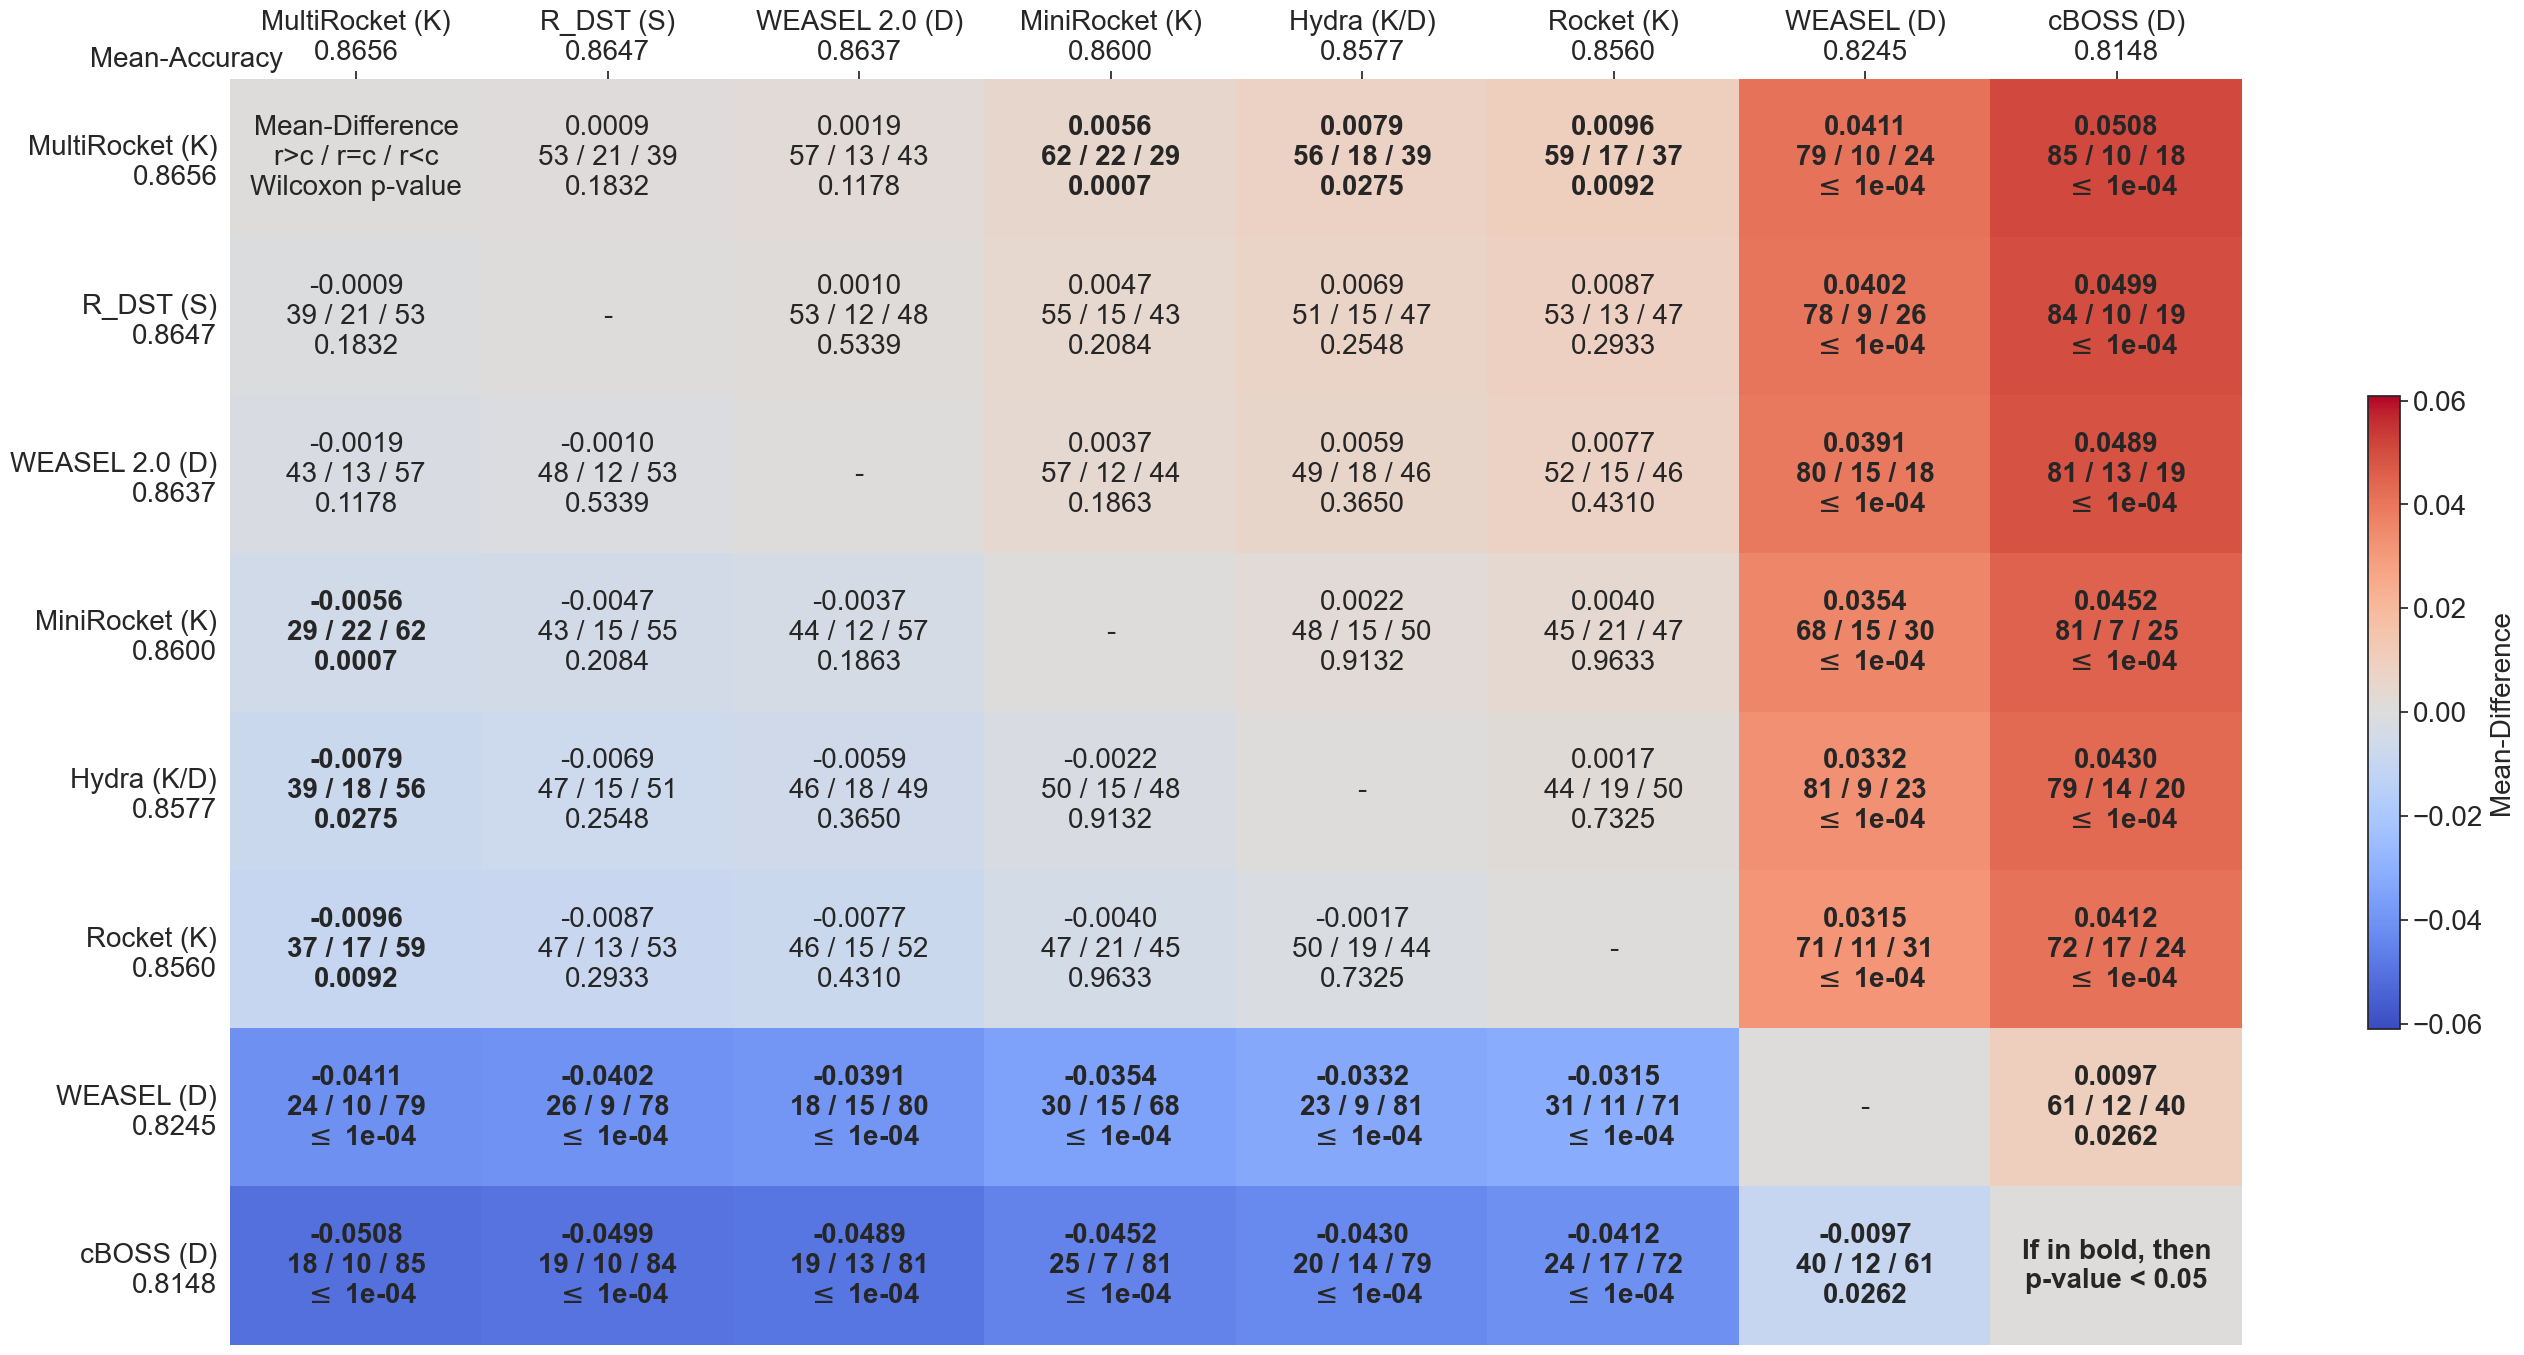

In [28]:
df_mcm = df_clean.copy()
df_mcm.index.name = "dataset_name"

os.makedirs("./mcm_output", exist_ok=True)

MCM.compare(
    output_dir="./mcm_output/",
    df_results=df_mcm,
    pdf_savename="heatmap",
    png_savename="heatmap",
    fig_size="28, 14",
    font_size="20",
)

display(Image(filename="./mcm_output/heatmap.png"))

-EOF-